# ECG Arrhythmia Classification — MIT-BIH Baseline

This notebook builds a first deep learning baseline for ECG heartbeat classification.

The workflow is:

1. Load raw ECG records and annotations from the MIT-BIH Arrhythmia Database.
2. Extract fixed-size heartbeat windows around expert annotations.
3. Normalize each heartbeat.
4. Map MIT-BIH annotation symbols into five classes.
5. Train a 1D-CNN with PyTorch.
6. Evaluate the model with accuracy, precision, recall, F1-score and confusion matrices.

The notebook is designed to run both locally and on Google Colab.

In [55]:
# Install missing packages only when running on Google Colab

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q wfdb tqdm

In [56]:
# Imports

from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
import wfdb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [57]:
# Project paths
# If the notebook is inside a notebooks/ folder, the project root is the parent folder.

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

MODELS_DIR = PROJECT_ROOT / "models"
CACHE_DIR = PROJECT_ROOT / "cache"

MODELS_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Models directory:", MODELS_DIR)
print("Cache directory:", CACHE_DIR)

Project root: c:\Users\aToMi\Desktop\Cours\ING 2\upf\deep learning\Projet
Models directory: c:\Users\aToMi\Desktop\Cours\ING 2\upf\deep learning\Projet\models
Cache directory: c:\Users\aToMi\Desktop\Cours\ING 2\upf\deep learning\Projet\cache


In [58]:
# Reproducibility and device selection

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device used:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No CUDA GPU detected.")

Device used: cuda
GPU: NVIDIA GeForce RTX 3090


## 1. Dataset and annotation mapping

The MIT-BIH Arrhythmia Database contains ECG recordings with expert beat annotations.

For this baseline, each annotated heartbeat is converted into one training sample.  
A fixed window is extracted around the annotation location, then normalized.

In [59]:
# MIT-BIH record list

MITBIH_RECORDS = [
    "100", "101", "102", "103", "104", "105", "106", "107",
    "108", "109", "111", "112", "113", "114", "115", "116",
    "117", "118", "119", "121", "122", "123", "124",
    "200", "201", "202", "203", "205", "207", "208", "209",
    "210", "212", "213", "214", "215", "217", "219", "220",
    "221", "222", "223", "228", "230", "231", "232", "233", "234"
]

print("Number of records:", len(MITBIH_RECORDS))

Number of records: 48


In [60]:
# Annotation mapping
# The original MIT-BIH symbols are grouped into five heartbeat classes.

AAMI_MAPPING = {
    # Normal beats
    "N": 0,
    "L": 0,
    "R": 0,
    "e": 0,
    "j": 0,

    # Supraventricular ectopic beats
    "A": 1,
    "a": 1,
    "J": 1,
    "S": 1,

    # Ventricular ectopic beats
    "V": 2,
    "E": 2,

    # Fusion beats
    "F": 3,

    # Unknown, paced or unclassified beats
    "/": 4,
    "f": 4,
    "Q": 4
}

class_names = {
    0: "Normal",
    1: "Supraventricular",
    2: "Ventricular",
    3: "Fusion",
    4: "Unknown"
}

num_classes = len(class_names)

In [61]:
def extract_beats_from_record(record_name, before=90, after=97, channel=0, pn_dir="mitdb"):
    """
    Extract heartbeat windows from one MIT-BIH record.

    The beat position comes from the expert annotations.
    The final window length is before + after samples.
    """

    record = wfdb.rdrecord(record_name, pn_dir=pn_dir)
    annotation = wfdb.rdann(record_name, "atr", pn_dir=pn_dir)

    signal = record.p_signal[:, channel]

    beats = []
    labels = []

    for sample_index, symbol in zip(annotation.sample, annotation.symbol):
        if symbol not in AAMI_MAPPING:
            continue

        start = sample_index - before
        end = sample_index + after

        if start < 0 or end > len(signal):
            continue

        beat = signal[start:end].astype(np.float32)

        # Normalize each beat separately.
        beat_mean = beat.mean()
        beat_std = beat.std()

        if beat_std < 1e-8:
            continue

        beat = (beat - beat_mean) / beat_std

        beats.append(beat)
        labels.append(AAMI_MAPPING[symbol])

    beats = torch.tensor(np.array(beats), dtype=torch.float32)
    labels = torch.tensor(np.array(labels), dtype=torch.long)

    return beats, labels

## 2. Build the dataset from raw ECG records

The first run downloads the MIT-BIH records through WFDB and extracts the beats.  
The processed tensors are then cached locally to avoid rebuilding the dataset every time.

In [62]:
CACHE_FILE = CACHE_DIR / "mitbih_raw_beats.pt"

if CACHE_FILE.exists():
    saved_data = torch.load(CACHE_FILE, map_location="cpu", weights_only=False)
    X = saved_data["X"]
    y = saved_data["y"]
    record_ids = saved_data["record_ids"]

    print("Loaded cached dataset.")

else:
    all_beats = []
    all_labels = []
    all_record_ids = []

    for record_name in tqdm(MITBIH_RECORDS, desc="Processing MIT-BIH records"):
        beats, labels = extract_beats_from_record(record_name)

        all_beats.append(beats)
        all_labels.append(labels)
        all_record_ids.extend([record_name] * len(labels))

    X = torch.cat(all_beats, dim=0)
    y = torch.cat(all_labels, dim=0)
    record_ids = np.array(all_record_ids)

    torch.save(
        {
            "X": X,
            "y": y,
            "record_ids": record_ids
        },
        CACHE_FILE
    )

    print("Saved processed dataset to cache.")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", torch.unique(y, return_counts=True))

Loaded cached dataset.
X shape: torch.Size([109466, 187])
y shape: torch.Size([109466])
Labels: (tensor([0, 1, 2, 3, 4]), tensor([90606,  2781,  7235,   802,  8042]))


Class distribution:
0 - Normal: 90606 samples (82.77%)
1 - Supraventricular: 2781 samples (2.54%)
2 - Ventricular: 7235 samples (6.61%)
3 - Fusion: 802 samples (0.73%)
4 - Unknown: 8042 samples (7.35%)


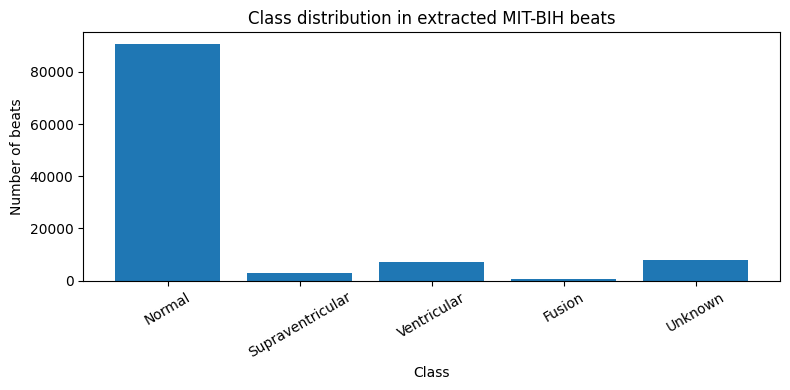

In [63]:
# Class distribution

def count_classes(labels, num_classes):
    return torch.bincount(labels.cpu(), minlength=num_classes)


class_counts = count_classes(y, num_classes)

print("Class distribution:")
for class_id in range(num_classes):
    count = class_counts[class_id].item()
    percentage = 100 * count / len(y)
    print(f"{class_id} - {class_names[class_id]}: {count} samples ({percentage:.2f}%)")

plt.figure(figsize=(8, 4))
plt.bar([class_names[i] for i in range(num_classes)], class_counts.tolist())
plt.title("Class distribution in extracted MIT-BIH beats")
plt.xlabel("Class")
plt.ylabel("Number of beats")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

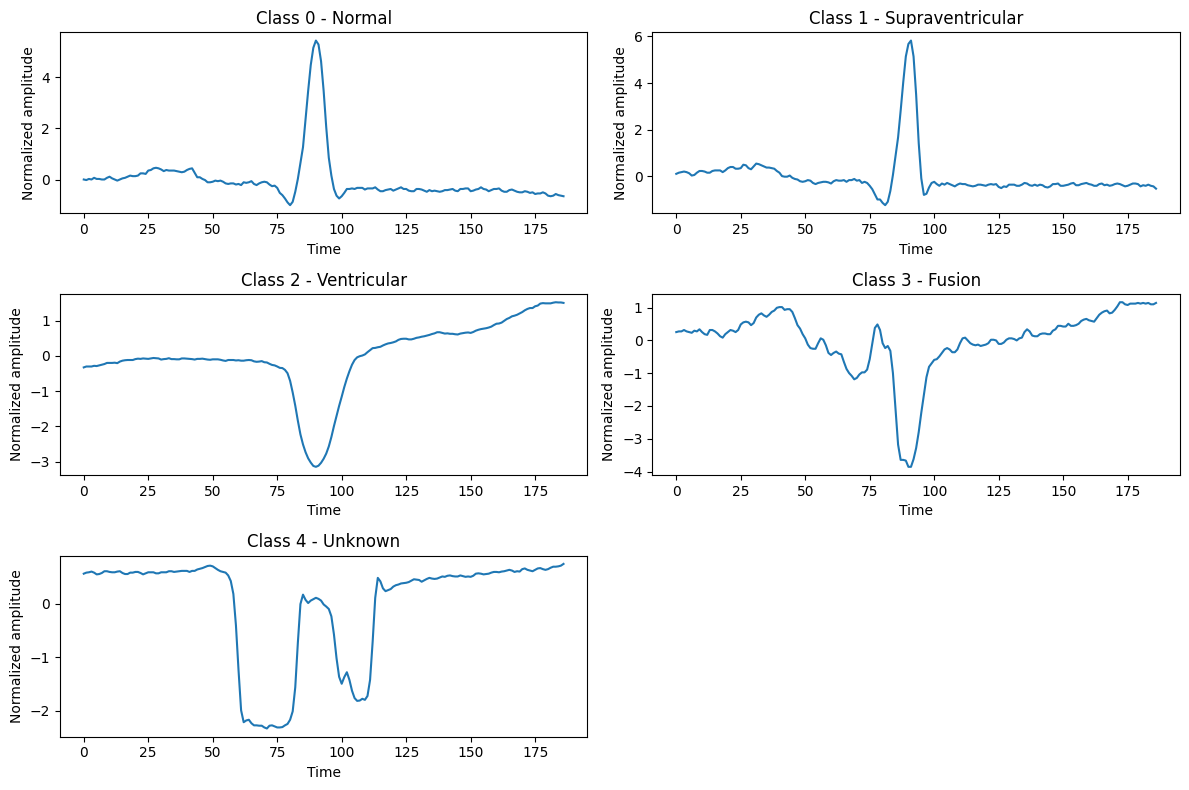

In [64]:
# Plot one example heartbeat per class

plt.figure(figsize=(12, 8))

for class_id in range(num_classes):
    indices = torch.where(y == class_id)[0]

    if len(indices) == 0:
        continue

    index = indices[0].item()
    beat = X[index]

    plt.subplot(3, 2, class_id + 1)
    plt.plot(beat)
    plt.title(f"Class {class_id} - {class_names[class_id]}")
    plt.xlabel("Time")
    plt.ylabel("Normalized amplitude")

plt.tight_layout()
plt.show()

## 3. Train, validation and test split

For this first baseline, a stratified beat-level split is used.  
This keeps the class proportions similar in the training, validation and test sets.

A stricter inter-patient split can be added later as an improvement.

In [65]:
def stratified_train_val_test_split(X, y, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15, seed=42):
    """
    Stratified split without scikit-learn.

    Each class is split separately, then the indices are shuffled.
    """

    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6

    generator = torch.Generator().manual_seed(seed)

    train_indices = []
    val_indices = []
    test_indices = []

    for class_id in torch.unique(y):
        class_indices = torch.where(y == class_id)[0]
        shuffled = class_indices[torch.randperm(len(class_indices), generator=generator)]

        n_total = len(shuffled)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        train_indices.append(shuffled[:n_train])
        val_indices.append(shuffled[n_train:n_train + n_val])
        test_indices.append(shuffled[n_train + n_val:])

    train_indices = torch.cat(train_indices)
    val_indices = torch.cat(val_indices)
    test_indices = torch.cat(test_indices)

    train_indices = train_indices[torch.randperm(len(train_indices), generator=generator)]
    val_indices = val_indices[torch.randperm(len(val_indices), generator=generator)]
    test_indices = test_indices[torch.randperm(len(test_indices), generator=generator)]

    X_train = X[train_indices]
    y_train = y[train_indices]

    X_val = X[val_indices]
    y_val = y[val_indices]

    X_test = X[test_indices]
    y_test = y[test_indices]

    return X_train, X_val, X_test, y_train, y_val, y_test


X_train, X_val, X_test, y_train, y_val, y_test = stratified_train_val_test_split(
    X,
    y,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=SEED
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: torch.Size([76624, 187]) torch.Size([76624])
Validation: torch.Size([16418, 187]) torch.Size([16418])
Test: torch.Size([16424, 187]) torch.Size([16424])


In [66]:
# Check class distribution after the split

for split_name, split_labels in [
    ("Train", y_train),
    ("Validation", y_val),
    ("Test", y_test)
]:
    print(f"\n{split_name} distribution:")
    split_counts = count_classes(split_labels, num_classes)

    for class_id in range(num_classes):
        count = split_counts[class_id].item()
        percentage = 100 * count / len(split_labels)
        print(f"{class_id} - {class_names[class_id]}: {count} samples ({percentage:.2f}%)")


Train distribution:
0 - Normal: 63424 samples (82.77%)
1 - Supraventricular: 1946 samples (2.54%)
2 - Ventricular: 5064 samples (6.61%)
3 - Fusion: 561 samples (0.73%)
4 - Unknown: 5629 samples (7.35%)

Validation distribution:
0 - Normal: 13590 samples (82.78%)
1 - Supraventricular: 417 samples (2.54%)
2 - Ventricular: 1085 samples (6.61%)
3 - Fusion: 120 samples (0.73%)
4 - Unknown: 1206 samples (7.35%)

Test distribution:
0 - Normal: 13592 samples (82.76%)
1 - Supraventricular: 418 samples (2.55%)
2 - Ventricular: 1086 samples (6.61%)
3 - Fusion: 121 samples (0.74%)
4 - Unknown: 1207 samples (7.35%)


## 4. PyTorch Dataset and DataLoaders

The CNN expects inputs with the shape:

```text
(batch_size, channels, signal_length)
```

Here, each heartbeat is a single-channel 1D signal.

In [67]:
class ECGDataset(Dataset):
    def __init__(self, signals, labels):
        self.signals = signals.float()
        self.labels = labels.long()

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, index):
        signal = self.signals[index]
        label = self.labels[index]

        # Conv1d expects a channel dimension.
        signal = signal.unsqueeze(0)

        return signal, label

In [68]:
BATCH_SIZE = 256

train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)
test_dataset = ECGDataset(X_test, y_test)

pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=pin_memory
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 300
Validation batches: 65
Test batches: 65


## 5. 1D-CNN model

A 1D convolutional network is used because ECG beats are one-dimensional time signals.  
The convolutional layers learn local waveform patterns such as peaks and morphology changes.

In [69]:
class ECG1DCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = ECG1DCNN(num_classes=num_classes).to(device)
print(model)

ECG1DCNN(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15

In [70]:
# Weighted loss to reduce the effect of class imbalance

train_counts = torch.bincount(y_train, minlength=num_classes).float()
safe_counts = torch.clamp(train_counts, min=1.0)

class_weights = len(y_train) / (num_classes * safe_counts)

# Very rare classes can create unstable weights, so the maximum value is limited.
class_weights = torch.clamp(class_weights, max=10.0).to(device)

print("Class counts:", train_counts)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Class counts: tensor([63424.,  1946.,  5064.,   561.,  5629.])
Class weights: tensor([ 0.2416,  7.8750,  3.0262, 10.0000,  2.7225], device='cuda:0')


## 6. Metrics

The metrics are implemented directly with PyTorch tensors, without scikit-learn.

In [71]:
def compute_accuracy(y_true, y_pred):
    return (y_true == y_pred).sum().item() / len(y_true)


def compute_confusion_matrix(y_true, y_pred, num_classes):
    indices = num_classes * y_true + y_pred

    matrix = torch.bincount(
        indices,
        minlength=num_classes * num_classes
    )

    return matrix.reshape(num_classes, num_classes)


def compute_precision_recall_f1(y_true, y_pred, num_classes):
    confusion = compute_confusion_matrix(y_true, y_pred, num_classes)

    precision_list = []
    recall_list = []
    f1_list = []

    for class_id in range(num_classes):
        true_positive = confusion[class_id, class_id].item()
        false_positive = confusion[:, class_id].sum().item() - true_positive
        false_negative = confusion[class_id, :].sum().item() - true_positive

        precision = true_positive / (true_positive + false_positive + 1e-8)
        recall = true_positive / (true_positive + false_negative + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

    macro_precision = sum(precision_list) / num_classes
    macro_recall = sum(recall_list) / num_classes
    macro_f1 = sum(f1_list) / num_classes

    return precision_list, recall_list, f1_list, macro_precision, macro_recall, macro_f1

## 7. Training and validation loops

In [72]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    for signals, labels in loader:
        signals = signals.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(signals)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * signals.size(0)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.append(predictions.detach().cpu())
        all_labels.append(labels.detach().cpu())

    all_predictions = torch.cat(all_predictions)
    all_labels = torch.cat(all_labels)

    epoch_loss = total_loss / len(loader.dataset)
    epoch_accuracy = compute_accuracy(all_labels, all_predictions)

    _, _, _, _, _, epoch_macro_f1 = compute_precision_recall_f1(
        all_labels,
        all_predictions,
        num_classes
    )

    return epoch_loss, epoch_accuracy, epoch_macro_f1


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for signals, labels in loader:
            signals = signals.to(device)
            labels = labels.to(device)

            outputs = model(signals)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * signals.size(0)

            predictions = torch.argmax(outputs, dim=1)

            all_predictions.append(predictions.cpu())
            all_labels.append(labels.cpu())

    all_predictions = torch.cat(all_predictions)
    all_labels = torch.cat(all_labels)

    epoch_loss = total_loss / len(loader.dataset)
    epoch_accuracy = compute_accuracy(all_labels, all_predictions)

    _, _, _, _, _, epoch_macro_f1 = compute_precision_recall_f1(
        all_labels,
        all_predictions,
        num_classes
    )

    return epoch_loss, epoch_accuracy, epoch_macro_f1, all_labels, all_predictions

In [73]:
EPOCHS = 15

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_macro_f1": [],
    "val_macro_f1": []
}

best_val_f1 = 0.0
best_model_path = MODELS_DIR / "best_mitbih_cnn1d.pt"

for epoch in range(EPOCHS):
    train_loss, train_accuracy, train_macro_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy, val_macro_f1, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)
    history["train_macro_f1"].append(train_macro_f1)
    history["val_macro_f1"].append(val_macro_f1)

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Train Macro-F1: {train_macro_f1:.4f} || "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f}"
    )

print("Best validation macro-F1:", round(best_val_f1, 4))
print("Best model saved to:", best_model_path)

Epoch [1/15] Train Loss: 0.5068 | Train Acc: 0.7981 | Train Macro-F1: 0.5800 || Val Loss: 0.3497 | Val Acc: 0.8669 | Val Macro-F1: 0.6654
Epoch [2/15] Train Loss: 0.3038 | Train Acc: 0.8803 | Train Macro-F1: 0.6891 || Val Loss: 0.4236 | Val Acc: 0.5802 | Val Macro-F1: 0.6239
Epoch [3/15] Train Loss: 0.2580 | Train Acc: 0.8992 | Train Macro-F1: 0.7210 || Val Loss: 0.2377 | Val Acc: 0.8930 | Val Macro-F1: 0.7792
Epoch [4/15] Train Loss: 0.2327 | Train Acc: 0.9075 | Train Macro-F1: 0.7371 || Val Loss: 0.2957 | Val Acc: 0.9696 | Val Macro-F1: 0.8590
Epoch [5/15] Train Loss: 0.2035 | Train Acc: 0.9145 | Train Macro-F1: 0.7489 || Val Loss: 0.3763 | Val Acc: 0.8315 | Val Macro-F1: 0.6800
Epoch [6/15] Train Loss: 0.2001 | Train Acc: 0.9135 | Train Macro-F1: 0.7508 || Val Loss: 0.2163 | Val Acc: 0.9513 | Val Macro-F1: 0.8396
Epoch [7/15] Train Loss: 0.1812 | Train Acc: 0.9230 | Train Macro-F1: 0.7659 || Val Loss: 0.2256 | Val Acc: 0.9081 | Val Macro-F1: 0.7613
Epoch [8/15] Train Loss: 0.1721 | 

## 8. Learning curves

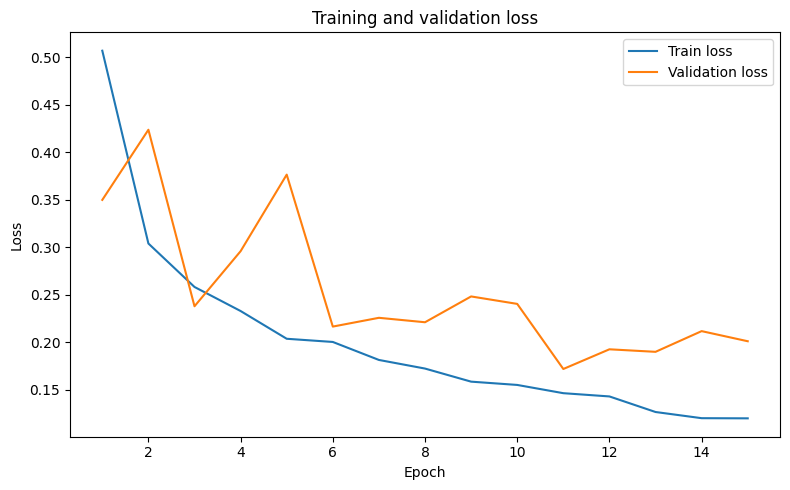

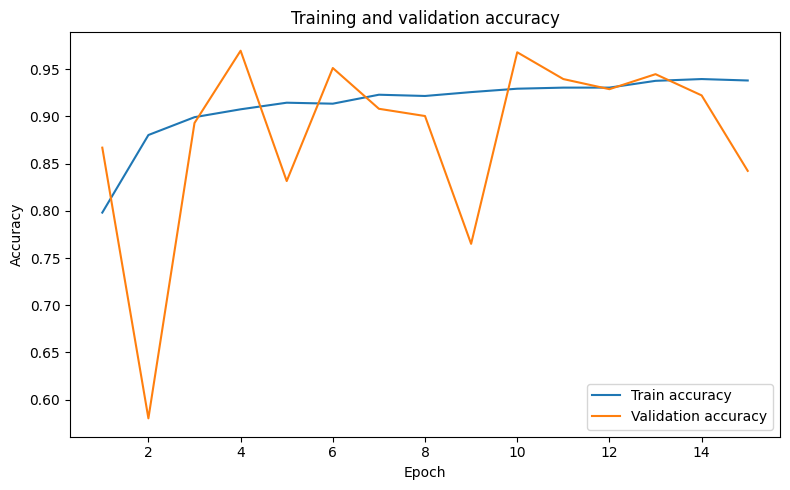

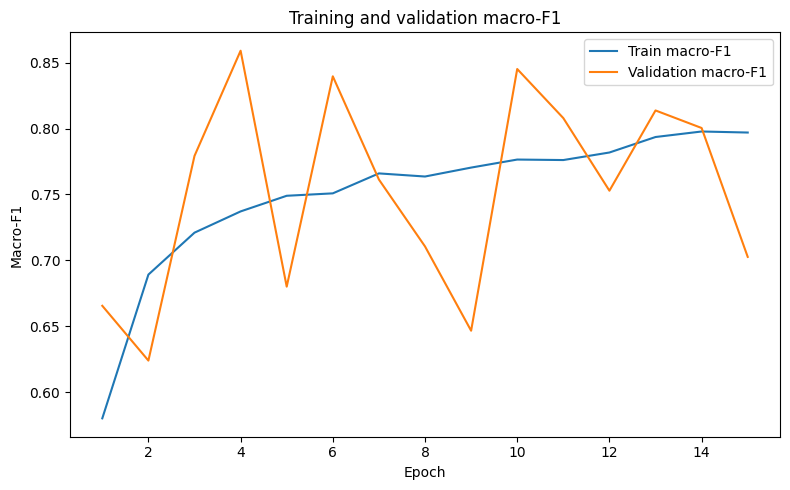

In [74]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train loss")
plt.plot(epochs_range, history["val_loss"], label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_accuracy"], label="Train accuracy")
plt.plot(epochs_range, history["val_accuracy"], label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_macro_f1"], label="Train macro-F1")
plt.plot(epochs_range, history["val_macro_f1"], label="Validation macro-F1")
plt.title("Training and validation macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Final evaluation on the test set

In [75]:
best_model = ECG1DCNN(num_classes=num_classes).to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_accuracy, test_macro_f1, y_true, y_pred = evaluate(
    best_model,
    test_loader,
    criterion,
    device
)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))
print("Test macro-F1:", round(test_macro_f1, 4))

Test loss: 0.2738
Test accuracy: 0.9711
Test macro-F1: 0.8636


In [76]:
precision_list, recall_list, f1_list, macro_precision, macro_recall, macro_f1 = compute_precision_recall_f1(
    y_true,
    y_pred,
    num_classes
)

print("Classification report")
print("-" * 80)
print(f"{'Class':<25} {'Precision':<12} {'Recall':<12} {'F1-score':<12} {'Support':<12}")
print("-" * 80)

for class_id in range(num_classes):
    support = (y_true == class_id).sum().item()

    print(
        f"{class_names[class_id]:<25} "
        f"{precision_list[class_id]:<12.4f} "
        f"{recall_list[class_id]:<12.4f} "
        f"{f1_list[class_id]:<12.4f} "
        f"{support:<12}"
    )

print("-" * 80)
print(f"{'Macro average':<25} {macro_precision:<12.4f} {macro_recall:<12.4f} {macro_f1:<12.4f}")
print(f"{'Accuracy':<25} {test_accuracy:<12.4f}")

Classification report
--------------------------------------------------------------------------------
Class                     Precision    Recall       F1-score     Support     
--------------------------------------------------------------------------------
Normal                    0.9883       0.9790       0.9836       13592       
Supraventricular          0.6591       0.6938       0.6760       418         
Ventricular               0.9202       0.9659       0.9425       1086        
Fusion                    0.6265       0.8595       0.7247       121         
Unknown                   0.9885       0.9942       0.9913       1207        
--------------------------------------------------------------------------------
Macro average             0.8365       0.8985       0.8636      
Accuracy                  0.9711      


In [77]:
confusion = compute_confusion_matrix(y_true, y_pred, num_classes)

print("Confusion matrix:")
print(confusion)

Confusion matrix:
tensor([[13306,   147,    72,    54,    13],
        [  125,   290,     2,     1,     0],
        [   26,     3,  1049,     7,     1],
        [    4,     0,    13,   104,     0],
        [    3,     0,     4,     0,  1200]])


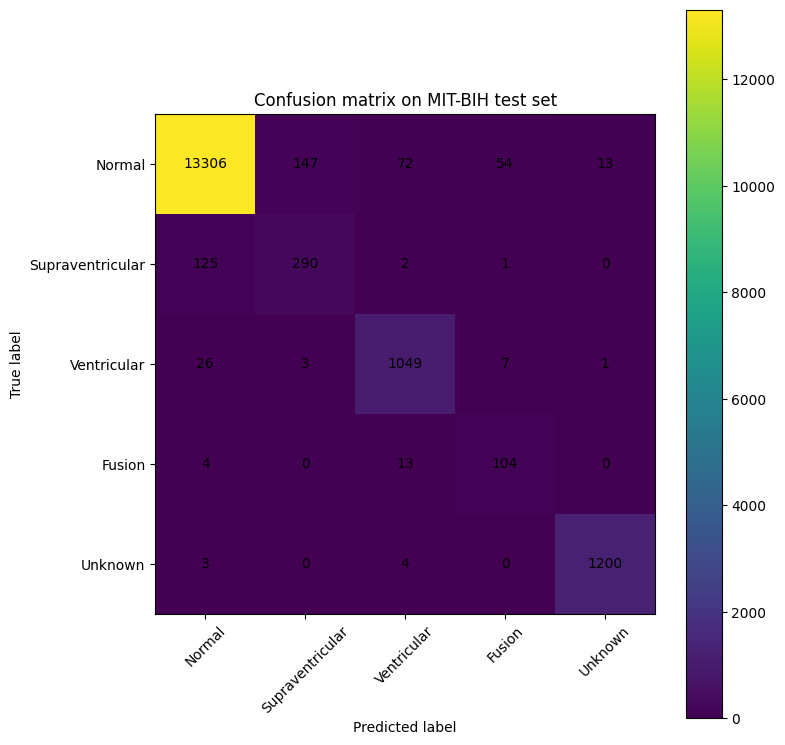

In [78]:
plt.figure(figsize=(8, 8))
plt.imshow(confusion)

plt.title("Confusion matrix on MIT-BIH test set")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(
    ticks=range(num_classes),
    labels=[class_names[i] for i in range(num_classes)],
    rotation=45
)

plt.yticks(
    ticks=range(num_classes),
    labels=[class_names[i] for i in range(num_classes)]
)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            str(confusion[i, j].item()),
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [79]:
normalized_confusion = confusion.float() / (confusion.float().sum(dim=1, keepdim=True) + 1e-8)

print("Normalized confusion matrix:")
print(normalized_confusion)

Normalized confusion matrix:
tensor([[9.7896e-01, 1.0815e-02, 5.2972e-03, 3.9729e-03, 9.5644e-04],
        [2.9904e-01, 6.9378e-01, 4.7847e-03, 2.3923e-03, 0.0000e+00],
        [2.3941e-02, 2.7624e-03, 9.6593e-01, 6.4457e-03, 9.2081e-04],
        [3.3058e-02, 0.0000e+00, 1.0744e-01, 8.5950e-01, 0.0000e+00],
        [2.4855e-03, 0.0000e+00, 3.3140e-03, 0.0000e+00, 9.9420e-01]])


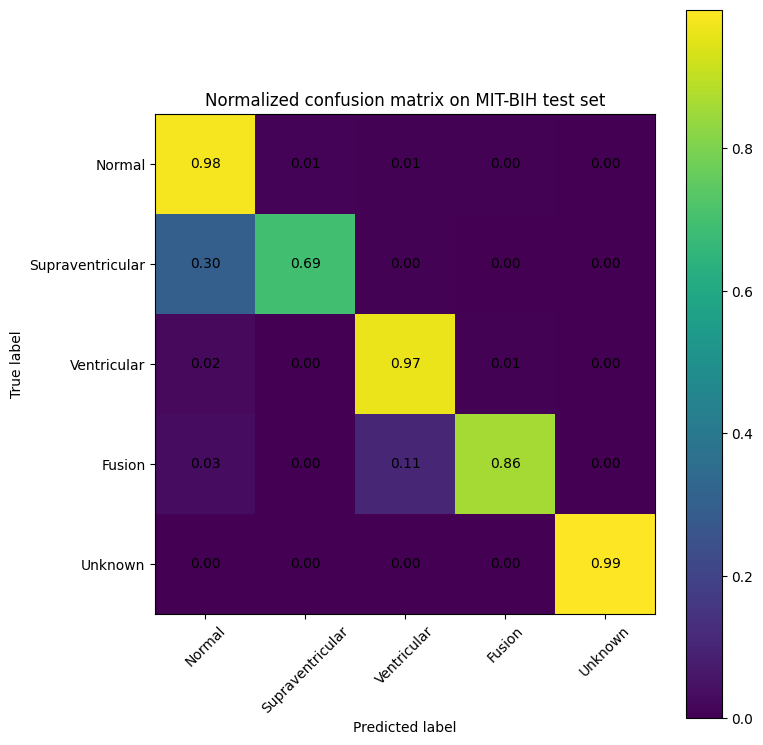

In [80]:
plt.figure(figsize=(8, 8))
plt.imshow(normalized_confusion)

plt.title("Normalized confusion matrix on MIT-BIH test set")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(
    ticks=range(num_classes),
    labels=[class_names[i] for i in range(num_classes)],
    rotation=45
)

plt.yticks(
    ticks=range(num_classes),
    labels=[class_names[i] for i in range(num_classes)]
)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            f"{normalized_confusion[i, j].item():.2f}",
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

### Summary of test results

| Metric | Value |
|---|---:|
| Test accuracy | 0.9711 |
| Macro precision | 0.8365 |
| Macro recall | 0.8985 |
| Macro-F1 | 0.8636 |

| Class | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Normal | 0.9883 | 0.9790 | 0.9836 |
| Supraventricular | 0.6591 | 0.6938 | 0.6760 |
| Ventricular | 0.9202 | 0.9659 | 0.9425 |
| Fusion | 0.6265 | 0.8595 | 0.7247 |
| Unknown | 0.9885 | 0.9942 | 0.9913 |

## Results analysis

The 1D-CNN baseline obtains strong overall results, with a test accuracy of **97.11%** and a macro-F1 score of **0.8636**. Since the dataset is imbalanced, the macro-F1 score is more relevant than accuracy alone, because it gives the same importance to all classes.

The model performs very well on **Normal**, **Ventricular**, and **Unknown** beats. These classes reach high F1-scores, showing that the CNN can extract useful temporal patterns from the ECG heartbeat segments.

The most difficult classes are **Supraventricular** and **Fusion** beats. The confusion matrix shows that several supraventricular beats are classified as normal, while some fusion beats are confused with ventricular beats. This is an important limitation, especially in a medical context where false negatives are critical.
